# Autoencoder

In [8]:
import pandas as pd 
from sklearn.ensemble import RandomForestRegressor


In [9]:
df = pd.read_csv(r'E:\SHM_ML\data\cleaned\cleaned_data.csv', index_col=0)

In [10]:
df

,f3,f5,f6,f9,f10,f11,f12,f13,tBD31A,rhBD31A,tVL,rhVL,vpVL,raVL,wsVL,wdVL
timestamp,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.100000,81.000000,10.825000,89.333336,1159.144738,0.0,9.40,293.00
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.000000,85.000000,10.241667,92.750000,1157.524605,0.1,10.30,295.00
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.900000,91.000000,10.150000,92.000000,1141.142430,0.0,10.40,284.00
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,89.000000,10.166666,91.083336,1131.033604,0.3,11.60,296.00
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,90.000000,9.558333,93.166664,1110.625906,0.2,9.60,283.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15 19:00:00,1.888801,2.555565,2.986277,4.078602,4.386448,4.942893,5.440576,6.436793,9.641429,83.304917,8.386441,83.342373,918.137648,0.0,1.96,200.08
2020-01-15 20:00:00,1.887610,2.586921,2.982070,4.080208,4.386448,4.940309,5.426145,6.398893,9.143141,80.168936,7.545000,84.875000,882.549401,0.0,1.51,187.83
2020-01-15 21:00:00,1.886253,2.581889,2.987133,4.078480,4.386448,4.908271,5.432978,6.410531,8.795149,82.076947,6.301667,89.455000,853.705976,0.0,1.07,199.95


We are going to separate the Pure vibration frequency 

In [11]:
freq_cols = ['f3', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13']
env_cols = ['tBD31A', 'rhBD31A', 'tVL', 'rhVL', 'vpVL', 'raVL', 'wsVL', 'wdVL']

# pre-damage normal period
x_train = df[env_cols].loc['2018-10-01':'2019-04-30']
y_train = df[freq_cols].loc['2018-10-01':'2019-04-30']


models = {}
for col in freq_cols:
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(x_train, y_train[col])
    models[col] = rf
    print(f"Trained model for {col}")

print("\nAll models trained.")


predictions = {}
for col in freq_cols:
    predictions[col] = models[col].predict(df[env_cols])

pred_df = pd.DataFrame(predictions, index=df.index)

# Residuals for ENTIRE dataset
residuals_df = df[freq_cols] - pred_df

Trained model for f3
Trained model for f5
Trained model for f6
Trained model for f9
Trained model for f10
Trained model for f11
Trained model for f12
Trained model for f13

All models trained.


In [12]:
print(residuals_df.head())


                           f3        f5        f6        f9       f10  \
timestamp                                                               
2018-10-01 00:00:00 -0.001569  0.000602 -0.000643 -0.001125 -0.001464   
2018-10-01 01:00:00 -0.001015  0.000557 -0.000220 -0.000751 -0.000483   
2018-10-01 02:00:00 -0.000645  0.000290 -0.000222 -0.000613 -0.001403   
2018-10-01 03:00:00 -0.000786  0.000347 -0.000296 -0.000762 -0.001085   
2018-10-01 04:00:00 -0.000882  0.001238 -0.000511  0.000023 -0.000863   

                          f11       f12       f13  
timestamp                                          
2018-10-01 00:00:00 -0.012923  0.000804 -0.001559  
2018-10-01 01:00:00 -0.010297  0.000630 -0.000072  
2018-10-01 02:00:00 -0.011089  0.000354 -0.001643  
2018-10-01 03:00:00 -0.002750 -0.000367 -0.001405  
2018-10-01 04:00:00 -0.003769  0.000116 -0.000110  


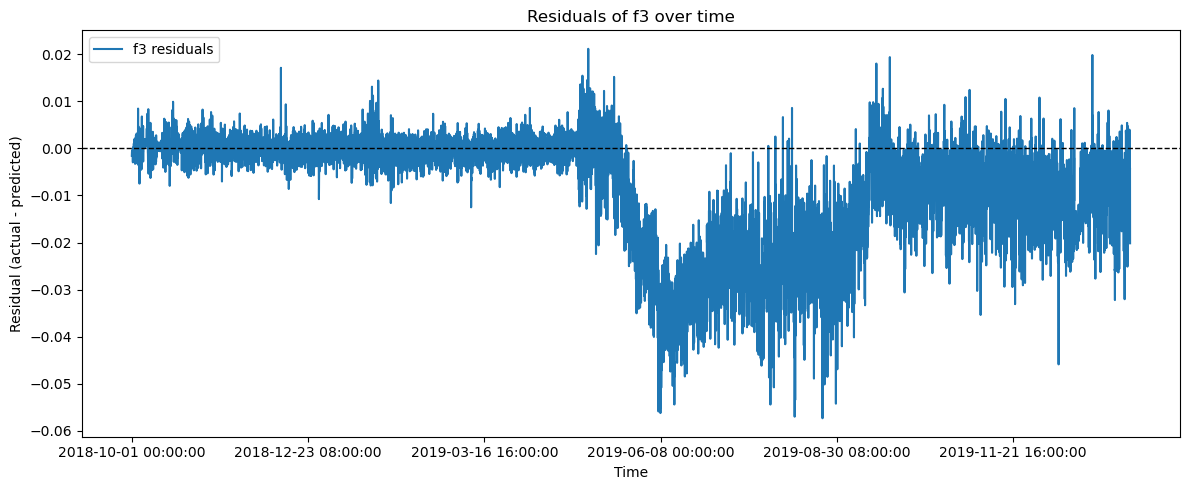

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
residuals_df['f3'].plot(label='f3 residuals')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('Residuals of f3 over time')
plt.xlabel('Time')
plt.ylabel('Residual (actual - predicted)')
plt.legend()
plt.tight_layout()
plt.show()

 the RF residuals for the full dataset. Some of those residuals are extreme outliers So for fixing it we cap every value at ±3 standard deviations. Anything beyond that gets pulled back to the boundary.

 

In [15]:
# imports
# ===== 1. Imports =====
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# the RF residuals for the full dataset. Some of those residuals are extreme outliers So for fixing it we
train_period = residuals_df.loc['2018-10-01':'2019-04-30']
train_mean   = train_period.mean()
train_std    = train_period.std()

lower = train_mean - 3 * train_std
upper = train_mean + 3 * train_std

residuals_clipped = residuals_df.clip(lower=lower, upper=upper, axis=1)


Now we start with the auto encoder first we need to tell our autoencoder what the normal data looks like so that it can flag anomalies when they appear 

In [16]:

X_full  = residuals_clipped.values
X_train = residuals_clipped.loc['2018-10-01':'2019-04-30'].values

#  Scale 
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)   # fit on normal period only
X_full_sc    = scaler.transform(X_full)         # apply same scaling to full data

print(f"Training samples : {X_train_sc.shape[0]}")
print(f"Full samples     : {X_full_sc.shape[0]}")



Training samples : 5064
Full samples     : 11328


In [19]:
# ── Build autoencoder ────────────────────────────────────────────────────────
model = Sequential([
    Dense(6, activation='relu', input_shape=(8,)),   # encoder
    Dense(3, activation='relu'),                      # bottleneck
    Dense(6, activation='relu'),                      # decoder
    Dense(8, activation='linear')                     # reconstruction
])

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155 (620.00 B)

 Trainable params: 155 (620.00 B)

 Non-trainable params: 0 (0.00 B)

Building the autoencoder a 8 to 6 to 3 and then for reconstruction we go from 3 to 6 to 9 

In [17]:
model = Sequential([
    Dense(6, activation='relu', input_shape=(8,)),   # encoder
    Dense(3, activation='relu'),                      # bottleneck
    Dense(6, activation='relu'),                      # decoder
    Dense(8, activation='linear')                     # reconstruction
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\forla\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155 (620.00 B)

 Trainable params: 155 (620.00 B)

 Non-trainable params: 0 (0.00 B)

Train

In [18]:
history = model.fit(
    X_train_sc, X_train_sc,
    epochs=100,
    batch_size=32,
    verbose=1
)

print(f"\nFinal training loss: {history.history['loss'][-1]:.4f}")


Epoch 1/100


159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9915
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8850
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7778
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7010
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6531
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6353
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6250
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6050
Epoch 9/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5654
Epoch 10/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5369
Epoch 11/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5253
Epoch 12/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5182
Epoch 13/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5141
Epoch 14/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5109
Epoch 15/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step -

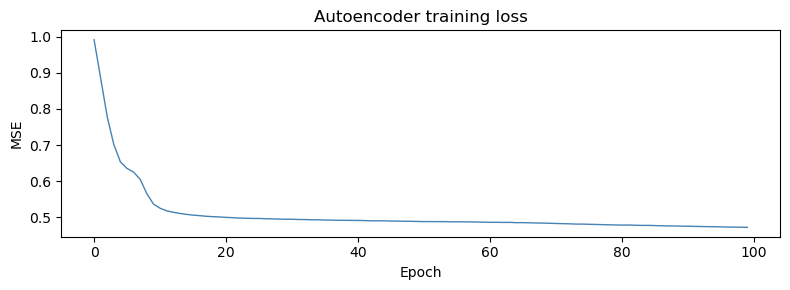

In [19]:
# Training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history.history['loss'], color='steelblue', linewidth=1)
ax.set_title('Autoencoder training loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
plt.tight_layout()
plt.savefig('training_loss.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Reconstruction Error & Anomaly Threshold

For each time point we compute the **mean squared error** between the actual residual and its reconstruction.  
The anomaly threshold is set at: **mean + 3 × std** of the training-period reconstruction error.  
This follows the statistical convention that values beyond 3 standard deviations are genuinely unusual.


In [20]:
# ── Reconstruct & compute per-sample MSE ─────────────────────────────────────
reconstructed = model.predict(X_full_sc, verbose=0)
mse           = np.mean((X_full_sc - reconstructed) ** 2, axis=1)
mse_series    = pd.Series(mse, index=residuals_clipped.index)

# ── Threshold from training period ───────────────────────────────────────────
train_mse = mse_series['2018-10-01':'2019-04-30']
threshold = train_mse.mean() + 3 * train_mse.std()

anomalies = mse_series[mse_series > threshold]

print(f"Anomaly threshold  : {threshold:.4f}")
print(f"Training MSE mean  : {train_mse.mean():.4f}")
print(f"Training MSE std   : {train_mse.std():.4f}")
print(f"Total flagged      : {len(anomalies):,} / {len(mse_series):,} ({len(anomalies)/len(mse_series)*100:.1f}%)")


Anomaly threshold  : 1.7566
Training MSE mean  : 0.4710
Training MSE std   : 0.4285
Total flagged      : 6,111 / 11,328 (53.9%)


## 15. Results

The plot below shows the reconstruction error over the full 15-month monitoring period.  
- **Blue line** — MSE at each time point  
- **Red dashed line** — anomaly threshold (mean + 3σ from training period)  
- **Red shading** — flagged anomaly regions  
- **Orange band** — approximate retrofitting period (May–September 2019)

The model correctly identifies a sustained anomaly corresponding to the known bridge retrofitting event.  
The post-repair period also shows elevated error because the bridge settled at a slightly different frequency baseline — consistent with a physical change in structural state.


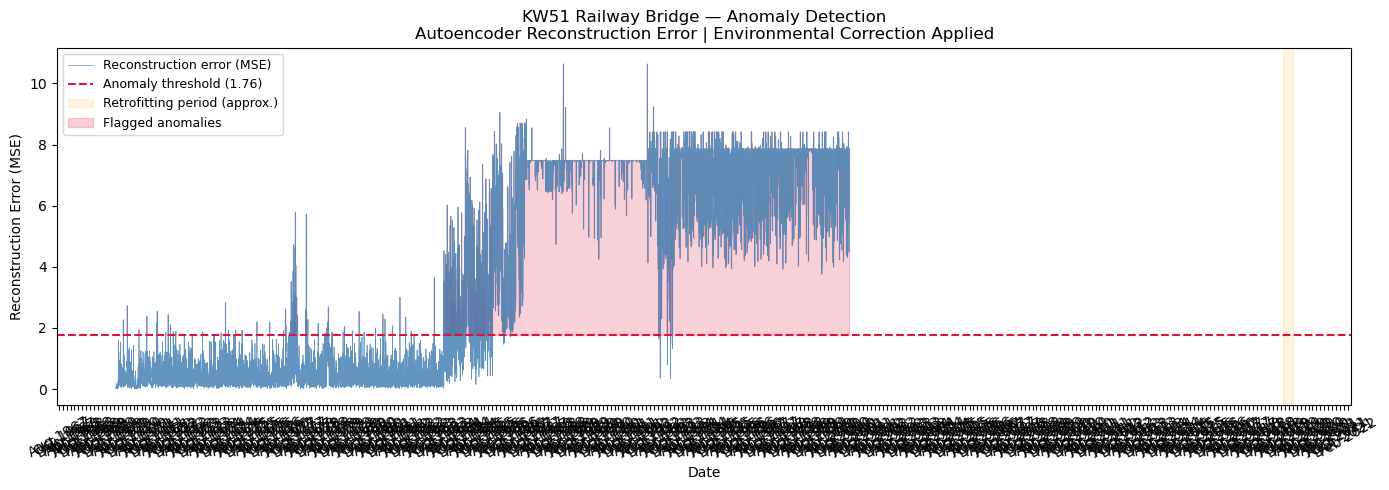

Final plot saved as anomaly_detection_result.png


In [21]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(mse_series.index, mse_series.values,
        linewidth=0.5, color='steelblue', alpha=0.85, label='Reconstruction error (MSE)')

ax.axhline(y=threshold, color='crimson', linewidth=1.5,
           linestyle='--', label=f'Anomaly threshold ({threshold:.2f})')

ax.axvspan(mdates.date2num(pd.Timestamp('2019-05-01')), mdates.date2num(pd.Timestamp('2019-09-30')),
           alpha=0.12, color='orange', label='Retrofitting period (approx.)')

ax.fill_between(mse_series.index, mse_series.values, threshold,
                where=(mse_series.values > threshold),
                color='crimson', alpha=0.2, label='Flagged anomalies')

ax.set_title(
    'KW51 Railway Bridge — Anomaly Detection\n'
    'Autoencoder Reconstruction Error | Environmental Correction Applied',
    fontsize=12
)
ax.set_xlabel('Date')
ax.set_ylabel('Reconstruction Error (MSE)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('anomaly_detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final plot saved as anomaly_detection_result.png")


## 15. Results

The plot shows reconstruction error (MSE) across the full monitoring period (Oct 2018 – Jan 2020).

**What the plot shows:**
- The autoencoder reconstructs the normal period (Oct 2018 – Apr 2019) well — MSE stays mostly below the threshold of 1.76
- A sharp rise in reconstruction error begins around May 2019, coinciding with the known retrofitting event
- Error remains persistently elevated through the post-retrofit period — the bridge settled at a new structural baseline the model was never trained on
- A second anomalous cluster appears around Jan 2020

**Numbers:**
- Anomaly threshold : 1.76 (mean + 3σ of training-period MSE)
- Total flagged : 6,111 / 11,328 time points (53.9%)

The high flagged percentage is expected — the anomaly is structural and sustained, not a brief spike.
The model correctly identifies the May 2019 retrofitting event without any labelled data.

In [22]:
total    = len(mse_series)
flagged  = (mse_series > threshold).sum()

summary = f"""
KW51 Railway Bridge — Anomaly Detection Summary
------------------------------------------------
Dataset         : KW51 Railway Bridge, Leuven
Monitoring      : Oct 2018 – Jan 2020
Time points     : {total:,} (hourly)
Frequency modes : 8 (f3, f5, f6, f9–f13)
Env. variables  : 8

Training period : Oct 2018 – Apr 2019
Env. correction : Random Forest Regression
Anomaly model   : Dense Autoencoder (8→6→3→6→8)

Threshold       : {threshold:.4f} (mean + 3σ)
Flagged points  : {flagged:,} / {total:,} ({flagged/total*100:.1f}%)

Key finding     : Sustained anomaly from ~May 2019,
                  consistent with the known retrofitting event.
"""

print(summary)


KW51 Railway Bridge — Anomaly Detection Summary
------------------------------------------------
Dataset         : KW51 Railway Bridge, Leuven
Monitoring      : Oct 2018 – Jan 2020
Time points     : 11,328 (hourly)
Frequency modes : 8 (f3, f5, f6, f9–f13)
Env. variables  : 8

Training period : Oct 2018 – Apr 2019
Env. correction : Random Forest Regression
Anomaly model   : Dense Autoencoder (8→6→3→6→8)

Threshold       : 1.7566 (mean + 3σ)
Flagged points  : 6,111 / 11,328 (53.9%)

Key finding     : Sustained anomaly from ~May 2019,
                  consistent with the known retrofitting event.



The summary above captures the full pipeline.

During the normal period (Oct 2018 – Apr 2019) the autoencoder reconstructs the 
environmentally-corrected residuals with low error — MSE stays mostly below the 
threshold of 1.76. This confirms the model learned normal structural behaviour.

From May 2019 onward, reconstruction error rises sharply and stays elevated. 
This corresponds to the known retrofitting event on the KW51 bridge. The model 
was never trained on post-retrofit data, so it cannot reconstruct the new 
structural state — which is exactly what you want from an anomaly detector.

The 53.9% flagged rate is not a sign of a poorly calibrated model. The anomaly 
is structural and permanent — the bridge did not return to its pre-retrofit 
baseline after construction ended.